# FPL Based Sampling

The goal here is to use the notion of the FPL values to drive how we sample. If we get a good rollout, the chances are that it would do better again. At the same time we still want to sample more often.

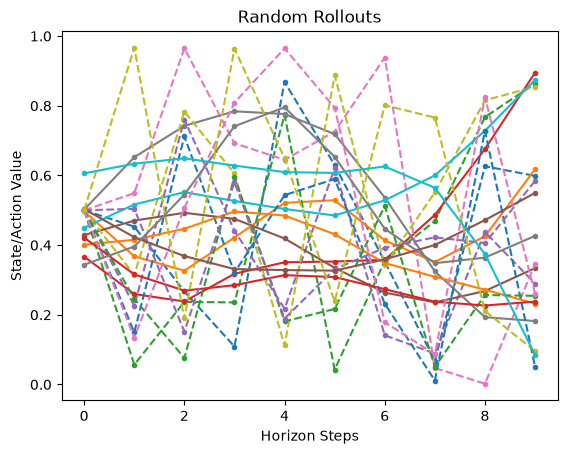

In [ ]:
import numpy as np
# Plot the rollouts
import matplotlib.pyplot as plt

def smoothness_curv_grad(u: np.ndarray) -> np.ndarray:
    """Gradient of the curvature roughness penalty S = Σ ||u_{i+1} - 2u_i + u_{i-1}||².

    Returns 2·L²u where L is the 1-D discrete Laplacian along time. Same shape as
    u (..., H, nu). Endpoints get one-sided contributions only.
    """
    d2 = u[..., 2:, :] - 2.0 * u[..., 1:-1, :] + u[..., :-2, :]   # (..., H-2, nu)
    g = np.zeros_like(u)
    g[..., :-2,  :] += 2.0 * d2     # contribution to u_{i-1}
    g[..., 1:-1, :] -= 4.0 * d2     # contribution to u_i
    g[..., 2:,   :] += 2.0 * d2     # contribution to u_{i+1}
    return g

# Creating N random rollouts for H horizon steps
N = 10 
H = 10
GD_SMOOTH = 5

# Set seed as a constant for reproducibility
np.random.seed(42)

# Creating a random rollout of shape (N, H, 1) where the last dimension represents (state, action)
rollouts = np.random.rand(N, H, 1)

# Create a ground truth smooth rollout for comparison
ground_truth = np.random.rand(1, H, 1)

# Make sure each rollout has the same starting point (e.g., 0) for consistency
rollouts[:, 0, 0] = 0.5
rollouts_smooth = np.copy(rollouts)

# Run GD just for smoothing
for _ in range(GD_SMOOTH):
    rollouts_smooth -= 0.05 * smoothness_curv_grad(rollouts_smooth)



for i in range(N):
    plt.plot(rollouts[i, :, 0], '.--', label=f'Rollout {i+1}')
    plt.plot(rollouts_smooth[i, :, 0], '.-', label=f'Smoothed Rollout {i+1}')
plt.title('Random Rollouts')
plt.xlabel('Horizon Steps')
plt.ylabel('State/Action Value')
plt.show()  

## Adaptive FPL-driven sampling — shared frontend

We turn the FPL fulfillment scores (`f_k ∈ [0,1]`, larger = better) into the *next* batch of samples. Two views that turn out to be the **same algorithm**:

- **Evolutionary resampler** — each parent spawns an integer number of children ∝ its FPL.
- **Multi-mode Gaussian (GMM)** — each parent is a Gaussian mode; mixture weight ∝ FPL and the per-mode **variance is set by FPL** (high FPL → tight, low FPL → wide).

A single commitment scalar `c ∈ [0,1]`, read off the **absolute** [0,1] scale, drives both the selection sharpness `β` and the exploration noise `σ` together:

| requirement | mechanism |
|---|---|
| proportional | mixture weight `π_k = softmax(β·f_k)` + per-mode `σ_k` shrinks with `f_k` |
| explore-when-bad | all-low `f` → `c≈0` → near-uniform `π` + wide `σ` (`σ_max`) |
| exploit-when-good | a high `f` → `c≈1` → peaked `π` + collapsed `σ` (`σ_min`) |
| absolute [0,1] scale | `c`, `β`, `σ` are explicit functions of raw `f` / `f_best` — never min-max renormalized |

In [83]:
# --- Shared FPL frontend: fitness -> commitment c -> beta -> mixture weights pi -> per-mode sigma ---
import numpy as np
import matplotlib.pyplot as plt

# toy constants the setup cell does not define
u_min, u_max, u_start = 0.0, 1.0, 0.5      # action bounds + pinned first knot
rng = np.random.default_rng(0)

# Children are curvature-smoothed, so a jagged random target is unreachable (the smoothness prior
# would cap achievable fitness). Replace ground_truth with a SMOOTH, reachable curve (start pinned)
# so convergence and the explore->exploit transition are demonstrable.
_t = np.linspace(0.0, 1.0, H)
ground_truth = (0.5 + 0.35 * np.sin(2.0 * np.pi * _t - 0.5)).reshape(1, H, 1)
ground_truth[0, 0, 0] = u_start

def fulfillment_toy(centers, ground_truth, ell=0.30):
    """Absolute [0,1] FPL surrogate: Gaussian on mean-over-horizon distance to ground_truth.
    centers (M,H,nu), ground_truth (1,H,nu) -> f (M,) in (0,1].
    In the REAL controller this is replaced by traj.reward (already [0,1]); ell is toy-only."""
    diff = centers - ground_truth[0][None]                 # (M,H,nu)
    mse = (diff ** 2).sum(axis=-1).mean(axis=-1)           # (M,)  mean_h ||.||^2
    return np.exp(-mse / (2.0 * ell ** 2))

def commitment(f, w_abs=0.7, g_ref=0.5):
    """Single explore<->exploit knob c in [0,1] from the absolute best + the gap to the mean."""
    f_best, f_mean = float(f.max()), float(f.mean())
    gap = f_best - f_mean
    return float(np.clip(w_abs * f_best + (1.0 - w_abs) * np.clip(gap / g_ref, 0.0, 1.0), 0.0, 1.0))

def beta_from_c(c, tau_hi=1.0, tau_lo=0.05):
    """Geometric temperature anneal -> selection inverse-temperature. c=0 soft, c=1 sharp."""
    return 1.0 / (tau_hi * (tau_lo / tau_hi) ** c)

def mixture_weights(f, beta):
    """Proportional weights softmax(beta*f); log-sum-exp stable with uniform fallback."""
    z = beta * f
    z = z - z.max()
    w = np.exp(z)
    s = w.sum()
    if s > 0 and np.isfinite(s):
        return w / s
    return np.full(f.shape[0], 1.0 / f.shape[0])

def sigma_global_from_c(c, sigma_min=0.02, sigma_max=0.5, kappa=2.0):
    """Global exploration scale: sigma_max at c=0 (explore) -> sigma_min at c=1 (exploit)."""
    return sigma_min + (sigma_max - sigma_min) * (1.0 - c) ** kappa

def per_mode_sigma(f, c, sigma_min=0.02, sigma_max=0.5, kappa=2.0, eps_floor=0.05,
                   width_mode="afper", kappa_c=1.0):
    """Per-mode std as a DECREASING function of FPL (the variance-from-FPL ask).
    'afper': sigma_global*(eps_floor+(1-eps_floor)*(1-f)) -> reduces to the evolutionary sigma_i.
    'convex': (1-c)^kappa_c * [sigma_min+(sigma_max-sigma_min)*(1-f)^kappa]."""
    sg = sigma_global_from_c(c, sigma_min, sigma_max, kappa)
    if width_mode == "afper":
        s = sg * (eps_floor + (1.0 - eps_floor) * (1.0 - f))
    elif width_mode == "convex":
        s = (1.0 - c) ** kappa_c * (sigma_min + (sigma_max - sigma_min) * (1.0 - f) ** kappa)
    else:
        raise ValueError(f"width_mode must be 'afper' or 'convex', got {width_mode!r}")
    return np.maximum(s, eps_floor * sigma_min)               # sigma_floor = eps_floor*sigma_min

def _frontend(f, w_abs=0.7, g_ref=0.5, tau_hi=1.0, tau_lo=0.05,
              sigma_min=0.02, sigma_max=0.5, kappa=2.0, eps_floor=0.05,
              width_mode="afper", kappa_c=1.0):
    """The full shared frontend used identically by both samplers -> (c, beta, pi, sigma_k, sigma_global)."""
    c = commitment(f, w_abs, g_ref)
    beta = beta_from_c(c, tau_hi, tau_lo)
    pi = mixture_weights(f, beta)
    sig = per_mode_sigma(f, c, sigma_min, sigma_max, kappa, eps_floor, width_mode, kappa_c)
    sg = sigma_global_from_c(c, sigma_min, sigma_max, kappa)
    return c, beta, pi, sig, sg

In [84]:
# --- Child pipeline + evolutionary resampler (AFPER) reference ---
def finish_children(kids):
    """Pin start -> curvature-smooth (reuse smoothness_curv_grad) -> re-pin -> clip.
    Re-pin AFTER smoothing because the discrete Laplacian perturbs knot 0."""
    kids = np.array(kids, dtype=float, copy=True)
    kids[:, 0, :] = u_start
    for _ in range(5):
        kids -= 0.05 * smoothness_curv_grad(kids)
        np.clip(kids, u_min, u_max, out=kids)
    kids[:, 0, :] = u_start
    return kids

def sus_picks(pi, R, rng):
    """Stochastic Universal Sampling: R evenly-spaced pointers under one random offset.
    Minimum-variance categorical allocation -> (R,) component indices."""
    cdf = np.cumsum(pi)
    u0 = rng.uniform(0.0, 1.0 / R)
    ptr = u0 + np.arange(R) / R
    return np.clip(np.searchsorted(cdf, ptr, side="right"), 0, len(pi) - 1)

def afper_step(centers, f, rng, N=None, n_elite=1, **P):
    """Evolutionary resampler: integer SUS offspring per parent + per-parent FPL noise + elitism.
    The accepted baseline; equals fpl_gmm_step(allocation='sus', width_mode='afper')."""
    M, H, nu = centers.shape
    N = M if N is None else N
    n_elite = min(n_elite, N - 1)
    c, beta, pi, sig, sg = _frontend(f, **P)
    elite = np.argsort(-f)[:n_elite]
    R = N - n_elite
    picks = sus_picks(pi, R, rng)
    kids = finish_children(centers[picks] + sig[picks][:, None, None] * rng.standard_normal((R, H, nu)))
    next_pop = np.concatenate([centers[elite], kids], axis=0)
    info = dict(c=c, beta=beta, pi=pi, sigma=sig, sigma_global=sg,
                counts=np.bincount(picks, minlength=M), f=f)
    return next_pop, info

## FPL-GMM — multi-mode Gaussian, variance from FPL

> *"a multi-mode gaussian where the variance is based on the FPL value."*

Each mode is centered on a parent; the proposal is `q(u) = Σ_k π_k · N(u; center_k, σ_k² I)` with `π_k = softmax(β·f_k)` (**weight ∝ FPL**) and `σ_k` **decreasing in f_k** (good mode → tight, bad mode → wide). We draw exactly `N` samples (elites kept verbatim) via the `allocation` switch: `'sus'` (low-variance integer offspring = the evolutionary resampler) or `'mixture'` (honest multinomial GMM draw).

In [85]:
# --- FPL-GMM: draw N samples from the FPL-weighted Gaussian mixture (allocation switch) ---
def fpl_gmm_step(centers, f, rng, N=None, n_elite=1, allocation="sus", **P):
    """Multi-mode Gaussian sampler. Each mode k is N(center_k, sigma_k^2 I) with mixture weight
    pi_k = softmax(beta*f_k) and per-mode std sigma_k decreasing in FPL. Draws exactly N samples
    (n_elite best kept verbatim) via:
      allocation='sus'     -> minimum-variance integer offspring (== the evolutionary resampler),
      allocation='mixture' -> honest multinomial categorical draw from the mixture.
    """
    M, H, nu = centers.shape
    N = M if N is None else N
    n_elite = min(n_elite, N - 1)
    c, beta, pi, sig, sg = _frontend(f, **P)
    elite = np.argsort(-f)[:n_elite]
    R = N - n_elite
    if allocation == "sus":
        counts = np.bincount(sus_picks(pi, R, rng), minlength=M)
    elif allocation == "mixture":
        counts = rng.multinomial(R, pi)
    else:
        raise ValueError(f"allocation must be 'sus' or 'mixture', got {allocation!r}")
    kid_list = [centers[i][None] + sig[i] * rng.standard_normal((int(counts[i]), H, nu))
                for i in range(M) if counts[i] > 0]
    kids = finish_children(np.concatenate(kid_list, axis=0)) if kid_list else np.empty((0, H, nu))
    next_pop = np.concatenate([centers[elite], kids], axis=0)
    assert next_pop.shape[0] == N, (next_pop.shape, N)
    info = dict(c=c, beta=beta, pi=pi, sigma=sig, sigma_global=sg, counts=counts, f=f)
    return next_pop, info

In [86]:
# --- Equivalence: allocation='sus' + width_mode='afper' reproduces the evolutionary resampler ---
f_eq = fulfillment_toy(rollouts.copy(), ground_truth)
ra, rb = np.random.default_rng(7), np.random.default_rng(7)
_, ia = afper_step(rollouts.copy(), f_eq, ra)
_, ib = fpl_gmm_step(rollouts.copy(), f_eq, rb, allocation="sus")
assert np.array_equal(ia["counts"], ib["counts"]), (ia["counts"], ib["counts"])
assert np.allclose(ia["pi"], ib["pi"]) and np.allclose(ia["sigma"], ib["sigma"])
print("equivalence OK — identical SUS offspring counts:", ia["counts"])
print("(same π, same per-mode σ, same SUS allocation  ⇒  same child distribution)")

equivalence OK — identical SUS offspring counts: [0 1 1 3 0 1 0 1 1 1]
(same π, same per-mode σ, same SUS allocation  ⇒  same child distribution)


f range: [0.345, 0.743]  (want a usable spread, not all ~0 or all ~1)
c=0.632  beta=6.65  sigma_global=0.085


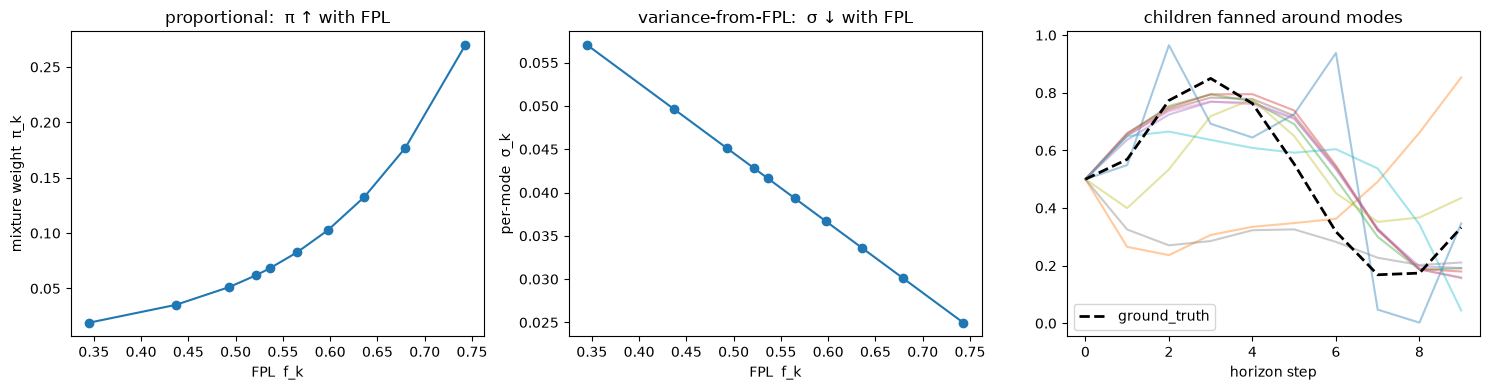

In [87]:
# --- Single-generation diagnostics: proportional weights + variance-from-FPL ---
f0 = fulfillment_toy(rollouts.copy(), ground_truth)            # generation-0 fitness
print(f"f range: [{f0.min():.3f}, {f0.max():.3f}]  (want a usable spread, not all ~0 or all ~1)")
next_pop, info = fpl_gmm_step(rollouts.copy(), f0, np.random.default_rng(1), allocation="mixture")
print(f"c={info['c']:.3f}  beta={info['beta']:.2f}  sigma_global={info['sigma_global']:.3f}")

order = np.argsort(f0)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(f0[order], info["pi"][order], "o-")
ax[0].set(xlabel="FPL  f_k", ylabel="mixture weight  π_k", title="proportional:  π ↑ with FPL")
ax[1].plot(f0[order], info["sigma"][order], "o-")
ax[1].set(xlabel="FPL  f_k", ylabel="per-mode  σ_k", title="variance-from-FPL:  σ ↓ with FPL")
for i in range(len(next_pop)):
    ax[2].plot(next_pop[i, :, 0], "-", alpha=0.4)
ax[2].plot(ground_truth[0, :, 0], "k--", lw=2, label="ground_truth")
ax[2].set(xlabel="horizon step", title="children fanned around modes"); ax[2].legend()
plt.tight_layout(); plt.show()

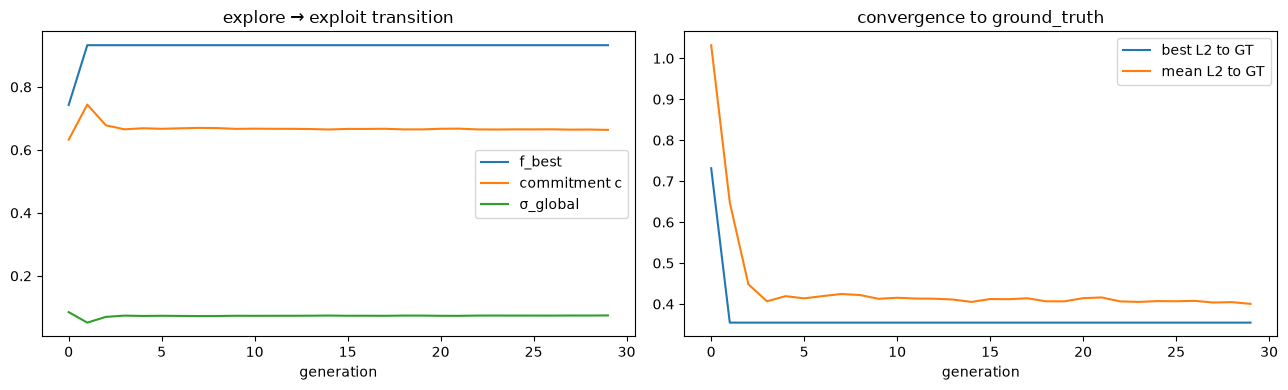

f_best 0.743 -> 0.933 | best L2 to GT 0.732 -> 0.355


In [88]:
# --- Multi-generation driver (allocation='sus' = evolutionary resampler) + transition/convergence ---
def l2_to_gt(centers, ground_truth):
    return np.sqrt(((centers - ground_truth[0][None]) ** 2).sum(axis=(1, 2)))

GENS = 30
rng_run = np.random.default_rng(0)
parents = rollouts.copy(); parents[:, 0, 0] = u_start
hist = []
for _ in range(GENS):
    f = fulfillment_toy(parents, ground_truth)
    d = l2_to_gt(parents, ground_truth)
    rec = dict(f_best=float(f.max()), f_mean=float(f.mean()), c=commitment(f),
               best_dist=float(d.min()), mean_dist=float(d.mean()))
    parents, info = afper_step(parents, f, rng_run)
    rec["sigma_global"] = info["sigma_global"]
    hist.append(rec)

g = np.arange(GENS)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(g, [h["f_best"] for h in hist], label="f_best")
ax[0].plot(g, [h["c"] for h in hist], label="commitment c")
ax[0].plot(g, [h["sigma_global"] for h in hist], label="σ_global")
ax[0].set(xlabel="generation", title="explore → exploit transition"); ax[0].legend()
ax[1].plot(g, [h["best_dist"] for h in hist], label="best L2 to GT")
ax[1].plot(g, [h["mean_dist"] for h in hist], label="mean L2 to GT")
ax[1].set(xlabel="generation", title="convergence to ground_truth"); ax[1].legend()
plt.tight_layout(); plt.show()

# invariants
fb = np.array([h["f_best"] for h in hist])
assert np.all(np.diff(fb) >= -1e-9), "elitism: f_best must be non-decreasing"
assert parents.shape[0] == N and np.allclose(parents[:, 0, 0], u_start)
print(f"f_best {hist[0]['f_best']:.3f} -> {hist[-1]['f_best']:.3f} | "
      f"best L2 to GT {hist[0]['best_dist']:.3f} -> {hist[-1]['best_dist']:.3f}")

## Persistent multi-mode registry — covering multiple basins

The single-mode evolutionary run collapses onto one optimum. The GMM's value-add is keeping several **distinct basins** alive across generations (spawn-distinct / merge-near / prune-weak). On a **bimodal** target, pure SUS collapses to one basin while the persistent GMM keeps a live mode in each.

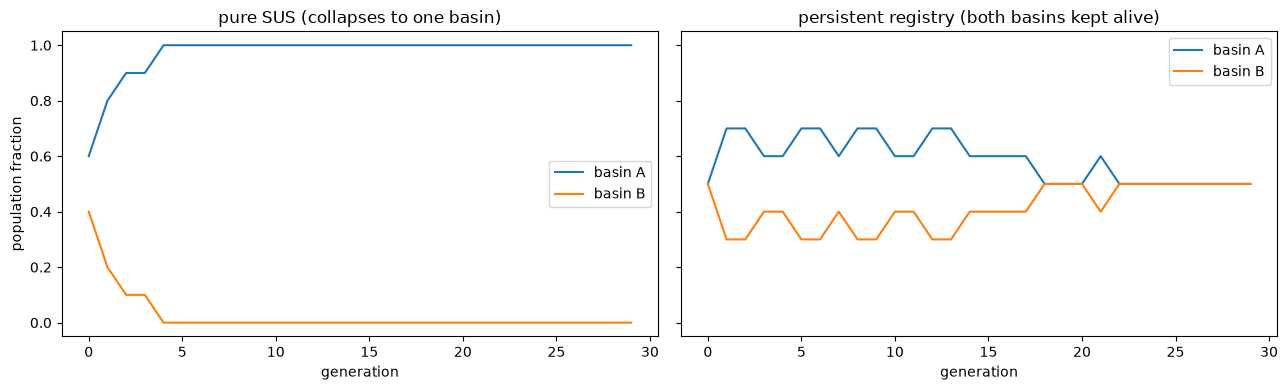

persistent registry final modes per basin:  A=1  B=1
pure-SUS final secondary-basin occupancy:        0.00  (collapse => ~0)
persistent-registry final secondary-basin occupancy: 0.50


In [89]:
# --- Persistent multi-mode registry + bimodal verification ---
nu = rollouts.shape[2]

def rms(a, b):
    """RMS distance between two trajectories (H, nu)."""
    return float(np.sqrt(((a - b) ** 2).sum(axis=-1).mean(axis=-1)))

def fitness_bimodal(centers, gts, ell=0.30):
    """Multi-modal fitness: best fulfillment over several ground-truth basins. gts: (B, H, nu)."""
    fs = [np.exp(-((centers - gts[b][None]) ** 2).sum(-1).mean(-1) / (2 * ell ** 2))
          for b in range(gts.shape[0])]
    return np.max(np.stack(fs, 0), axis=0)

def nearest_basin(centers, gts):
    d = np.stack([np.sqrt(((centers - gts[b][None]) ** 2).sum(axis=(1, 2)))
                  for b in range(gts.shape[0])], 0)
    return d.argmin(axis=0)

def consolidate(pop, pf, K_max, d_merge):
    """Spawn-distinct / merge-near / prune-weak in one greedy pass: keep the highest-FPL,
    spatially-distinct subset of trajectories (at most K_max)."""
    kept = []
    for idx in np.argsort(-pf):
        if all(rms(pop[idx], pop[j]) > d_merge for j in kept):
            kept.append(int(idx))
        if len(kept) >= K_max:
            break
    return pop[kept]

# Two distinct, reachable (smooth) ground-truth basins; both start pinned at u_start.
gt_a = ground_truth[0].copy(); gt_a[0, 0] = u_start
gt_b = 1.0 - ground_truth[0];  gt_b[0, 0] = u_start
gts = np.stack([gt_a, gt_b], 0)                       # (2, H, nu)

def run_bimodal(persist, gens=30, K_max=6, d_merge=0.20, min_per_mode=2, seed=1):
    """persist=False -> single population, allocation='sus' (collapses to one basin).
    persist=True  -> mode registry: each live mode gets a guaranteed >=min_per_mode children
    (per-mode variance from its own FPL), so distinct basins never starve; merge/prune via consolidate."""
    rng_l = np.random.default_rng(seed)
    pop = rollouts.copy(); pop[:, 0, 0] = u_start
    modes = consolidate(pop, fitness_bimodal(pop, gts), K_max, d_merge)
    occ = []
    for _ in range(gens):
        if persist:
            mf = fitness_bimodal(modes, gts)
            _, _, pi, sig, _ = _frontend(mf)
            M = len(modes)
            base = np.full(M, min_per_mode if M * min_per_mode <= N else 1)
            R = max(N - int(base.sum()), 0)
            counts = base + (np.bincount(sus_picks(pi, R, rng_l), minlength=M) if R > 0 else 0)
            kids = [modes[i][None] + sig[i] * rng_l.standard_normal((int(counts[i]), H, nu))
                    for i in range(M) if counts[i] > 0]
            pop = finish_children(np.concatenate(kids, 0))
            modes = consolidate(pop, fitness_bimodal(pop, gts), K_max, d_merge)
        else:
            pop, _ = fpl_gmm_step(pop, fitness_bimodal(pop, gts), rng_l, N=N, allocation="sus")
        nb = nearest_basin(pop, gts)
        occ.append([(nb == 0).mean(), (nb == 1).mean()])
    return np.array(occ), modes

occ_sus, _ = run_bimodal(persist=False)              # single-mode evolutionary -> collapses
occ_gmm, modes_gmm = run_bimodal(persist=True)       # persistent registry -> keeps both basins

fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
ax[0].plot(occ_sus[:, 0], label="basin A"); ax[0].plot(occ_sus[:, 1], label="basin B")
ax[0].set(xlabel="generation", ylabel="population fraction", title="pure SUS (collapses to one basin)"); ax[0].legend()
ax[1].plot(occ_gmm[:, 0], label="basin A"); ax[1].plot(occ_gmm[:, 1], label="basin B")
ax[1].set(xlabel="generation", title="persistent registry (both basins kept alive)"); ax[1].legend()
plt.tight_layout(); plt.show()

mb = nearest_basin(modes_gmm, gts)
print(f"persistent registry final modes per basin:  A={int((mb == 0).sum())}  B={int((mb == 1).sum())}")
print(f"pure-SUS final secondary-basin occupancy:        {occ_sus[-1].min():.2f}  (collapse => ~0)")
print(f"persistent-registry final secondary-basin occupancy: {occ_gmm[-1].min():.2f}")
assert (mb == 0).any() and (mb == 1).any(), "persistent registry should keep a live mode in each basin"